# v2-1. 데이터 다시 보기
v1 최종 데이터(```data/output/final_season_added.csv```)를 다시 열어보다가 이상한 점이 있어서 원본부터 다시 정리함

- 원본 월세 거래는 13만 건 정도인데 최종 데이터는 41만 행
- 주소에 있는 동이랑 좌표로 찾은 법정동이 다른 행이 많음

#### 이 노트북에서 하는 것
1. 기존 최종 데이터에서 문제 확인 (중복, 좌표 어긋남)
2. 원본에서 거래 테이블 다시 만들기 (v1 전처리 필터 그대로)
3. 주소와 좌표 짝 복구 + 검증
4. 입지 변수 다시 붙여서 ```data/rent_v2.csv.gz``` 저장

In [1]:
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트 (v1 streamlit/app2.py랑 같은 방식)
if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
else:
    plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# git lfs로 받은 v1 최종 데이터
OLD_PATH = '../data/output/final_season_added.csv'
# v1 Preprocessing.ipynb에서 아파트, 연립다세대 원본 2개를 concat 해서 저장했던 apt_vil_combined.csv (용량 때문에 gz로 압축)
RAW_PATH = 'data/apt_vil_combined.csv.gz'

## 1. 기존 최종 데이터 확인

In [2]:
old = pd.read_csv(OLD_PATH, low_memory=False)
raw = pd.read_csv(RAW_PATH, low_memory=False)

print('v1 최종 데이터 행 수  :', len(old))
print('완전히 똑같은 행 수    :', old.duplicated().sum())
print('원본(전세+월세) 행 수  :', len(raw))
print('원본 월세 행 수        :', (raw['전월세구분'] == '월세').sum())

v1 최종 데이터 행 수  : 413720
완전히 똑같은 행 수    : 289924
원본(전세+월세) 행 수  : 269178
원본 월세 행 수        : 136525


### 같은 거래가 몇 번씩 들어가 있는지
주소, 면적, 계약일, 금액, 층, 계약기간이 다 같으면 같은 거래로 봄

In [3]:
tx_cols = ['도로명', '전용면적(㎡)', '계약년', '계약월', '계약일', '보증금(만원)', '월세금(만원)',
           '층', '건축년도', '시작연', '시작월', '종료연', '종료월']
rep = old.groupby(tx_cols).size()
print('고유 거래 수          :', len(rep))
print('거래 1건당 평균 행 수 :', round(rep.mean(), 2))
print()
print('반복 횟수별 거래 수')
print(rep.value_counts().sort_index().head(12))

고유 거래 수          : 116271
거래 1건당 평균 행 수 : 3.56

반복 횟수별 거래 수
1     27312
2     26823
3     15453
4     17685
5      8475
6      4365
7      2166
8      5352
9      4561
10      339
11     2936
12      186
Name: count, dtype: int64


### 원인 1. 법정동 이름으로 merge 하면서 행이 늘어남
v1 Preprocessing.ipynb에서 행정동 코드를 붙일 때 **법정동 이름**으로 merge 했었음

```python
df00 = df00.merge(dong_subset, on="법정동", how="left")
```

```동_통합KIKmix``` 표는 법정동 1개가 행정동 여러 개로 나뉘어 있어서 1:N merge가 됨
예를 들어 ```신당동```은 행정동 6개라서 거래 1건이 6행이 됨

In [4]:
dong = pd.read_excel('../data/동_통합KIKmix.20250513.xlsx')
dong = dong[dong['시도명'] == '서울특별시']
print(dong[dong['동리명'] == '신당동'][['시군구명', '읍면동명', '동리명', '법정동코드']])

    시군구명   읍면동명  동리명       법정동코드
175   중구    신당동  신당동  1114016200
178   중구    다산동  신당동  1114016200
179   중구    약수동  신당동  1114016200
180   중구    청구동  신당동  1114016200
181   중구  신당제5동  신당동  1114016200
182   중구    동화동  신당동  1114016200


In [5]:
# 행이 반복된 횟수 == 그 법정동 이름이 매핑표에 나오는 횟수 인지 확인
match_cnt = dong.groupby('동리명').size()
same_rows = old.groupby(old.columns.tolist(), dropna=False).size().rename('반복').reset_index()
same_rows['매핑표 행 수'] = same_rows['법정동'].map(match_cnt)
print('반복 횟수 == 매핑표 행 수 :', round((same_rows['반복'] == same_rows['매핑표 행 수']).mean(), 4))

반복 횟수 == 매핑표 행 수 : 0.9672


-> 거의 다 매핑표 행 수만큼 복제된 것. 남은 일부는 이름이 같은 법정동이 다른 구에도 있어서 ```법정동코드```가 다른 행으로 갈라진 경우

### 원인 2. 주소의 동과 좌표의 법정동이 다름
```동```은 원본 주소에서 나온 값이고, ```법정동```은 좌표를 법정동 경계(shp)에 공간 조인해서 나온 값이라 원래는 같아야 함

주소의 동 == 좌표의 법정동 : 0.1387


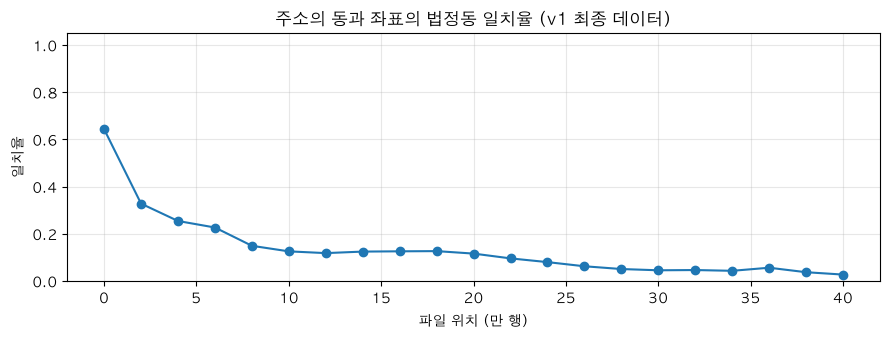

In [6]:
same = (old['동'] == old['법정동'])
print('주소의 동 == 좌표의 법정동 :', round(same.mean(), 4))

# 파일 앞에서부터 2만 행씩 끊어서 일치율
block = same.groupby(np.arange(len(old)) // 20000).mean()
plt.figure(figsize=(9, 3.5))
plt.plot(block.index * 2, block.values, marker='o')
plt.xlabel('파일 위치 (만 행)')
plt.ylabel('일치율')
plt.title('주소의 동과 좌표의 법정동 일치율 (v1 최종 데이터)')
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/01_dong_match.png', dpi=120)
plt.show()

맨 앞 7천여 행은 다 맞는데 뒤로 갈수록 떨어짐 -> 거래 정보랑 좌표 정보가 서로 다른 행에 붙어있음
7460번째 행 근처를 보면 좌표 쪽 값(```법정동```, ```위도```)이 한 칸씩 밀려있는게 보임

In [7]:
print(old.loc[7456:7470, ['동', '도로명', '법정동', '위도', '경도']])

          동                    도로명    법정동         위도          경도
7456  원효로4가  서울특별시 용산구 원효로4가118-16  원효로4가  37.532716  126.950381
7457    옥수동         서울특별시 성동구 옥수동4    옥수동  37.543692  127.018896
7458  광희동1가      서울특별시 중구 광희동1가166  광희동1가  37.564861  127.005920
7459    황학동       서울특별시 중구 황학동2523    황학동  37.566172  127.021909
7460    사근동     서울특별시 성동구 사근동210-4    황학동  37.566172  127.021909
7461  금호동4가     서울특별시 성동구 금호동4가235    사근동  37.561118  127.046143
7462    용답동      서울특별시 성동구 용답동69-2  금호동4가  37.546117  127.024069
7463    행당동       서울특별시 성동구 행당동380    용답동  37.565848  127.053327
7464    행당동       서울특별시 성동구 행당동349    행당동  37.555141  127.038383
7465    행당동       서울특별시 성동구 행당동349    행당동  37.555141  127.038383
7466    행당동       서울특별시 성동구 행당동349    행당동  37.555141  127.038383
7467  원효로1가      서울특별시 용산구 원효로1가41    행당동  37.554920  127.036080
7468  원효로1가      서울특별시 용산구 원효로1가41    행당동  37.554920  127.036080
7469  원효로1가      서울특별시 용산구 원효로1가41    행당동  37.554920  127.036080
7470  인현동2가      서울특별시 중구

### 입지 컬럼끼리는 좌표 기준으로 일관됨
같은 좌표인데 병원 개수나 인구비율이 다르면 입지 계산 자체가 틀린건데, 확인해보니 좌표가 같으면 값도 전부 같음
-> 입지 변수 계산은 맞았고 **거래랑 좌표의 짝만 어긋난 것**
(```법정동코드```만 값이 갈리는 건 원인 1의 이름 merge 때문)

In [8]:
loc_cols = ['병원_0.2km내_개수', '병원_0.5km내_개수', '병원_1km내_개수', '병원_3km내_개수', '병원_10km내_개수',
            '500m_이내_역_개수', '1km_이내_역_개수',
            '식당_0.2km내_개수', '식당_0.5km내_개수', '식당_1km내_개수',
            '공원_300m_이내_개수', '공원_500m_이내_개수', '공원_800m_이내_개수',
            '파출소/지구대_0.5km내_개수', '파출소/지구대_1km내_개수', '파출소/지구대_3km내_개수',
            '대학_0.2km내_개수', '대학_0.5km내_개수', '대학_1km내_개수', '대학_2km내_개수',
            '법정동', '행정동', '외국인_비율', '65세이상_인구비율', '0-19대인구비', '20-34대인구비', '35-64대인구비']

# 좌표를 문자열 키로 (소수점 7자리)
old['좌표'] = old['위도'].map('{:.7f}'.format) + ',' + old['경도'].map('{:.7f}'.format)
nun = old.groupby('좌표')[loc_cols + ['법정동코드']].nunique()
print('좌표 개수 :', len(nun))
print('좌표 하나에 값이 2개 이상인 비율 (상위 5개)')
print((nun > 1).mean().round(4).sort_values(ascending=False).head(5))

좌표 개수 : 36822
좌표 하나에 값이 2개 이상인 비율 (상위 5개)
법정동코드           0.0189
병원_0.5km내_개수    0.0000
35-64대인구비       0.0000
20-34대인구비       0.0000
0-19대인구비        0.0000
dtype: float64


## 2. 원본에서 거래 테이블 다시 만들기
v1 Preprocessing.ipynb 필터 그대로 적용
- ```계약기간```이 '-'인 행 제거
- 계약년보다 시작연이 빠른 행 제거
- 월세만 남기고 월세금 0 제거

In [9]:
com = raw.copy()
print('원본 :', len(com))

com['주소'] = com['시군구'] + com['번지'].astype(str)    # v1 '도로명' 컬럼이랑 같은 값 (카카오 API에 넣었던 지번 주소)
com['도로명주소'] = com['도로명']                          # 원본의 실제 도로명 주소 (서비스 화면용)
com['구'] = com['시군구'].str.split(expand=True)[1]
com['동'] = com['시군구'].str.split(expand=True)[2]
com['건물명'] = com['단지명'].fillna(com['건물명'])         # 아파트는 단지명, 연립다세대는 건물명에 들어있음

com['보증금(만원)'] = com['보증금(만원)'].astype(str).str.replace(',', '', regex=False).astype(int)
com['월세금(만원)'] = com['월세금(만원)'].astype(str).str.replace(',', '', regex=False).astype(int)
com['계약년'] = com['계약년월'] // 100
com['계약월'] = com['계약년월'] % 100

com = com[com['계약기간'] != '-'].copy()
print("계약기간 '-' 제거   :", len(com))

term = com['계약기간'].str.split('~', expand=True)
com['시작연'] = term[0].str[:4].astype(int)
com['시작월'] = term[0].str[4:].astype(int)
com['종료연'] = term[1].str[:4].astype(int)
com['종료월'] = term[1].str[4:].astype(int)
com['계약개월수'] = (com['종료연'] - com['시작연']) * 12 + (com['종료월'] - com['시작월'])

com = com[com['계약년'] <= com['시작연']]
print('시작연 < 계약년 제거 :', len(com))
com = com[com['전월세구분'] == '월세']
print('월세만               :', len(com))
com = com[com['월세금(만원)'] != 0]
print('월세금 0 제거        :', len(com))

원본 : 269178


계약기간 '-' 제거   : 247439
시작연 < 계약년 제거 : 247077


월세만               : 122486
월세금 0 제거        : 122474


-> v1 노트북에서 위경도 붙이기 전 행 수(122,474)랑 똑같이 나옴

## 3. 주소 - 좌표 짝 복구
카카오 API를 다시 돌리는 대신, 기존 파일 안에 이미 있는 좌표를 주소에 다시 맞춰줌

#### 아이디어
- 거래 쪽(주소)이랑 좌표 쪽은 순서는 거의 같은데 뒤로 갈수록 조금씩 밀려있음 (아래에서 확인)
- 같은 주소는 파일 안에서 날짜별로 여러 번 나옴
- 주소가 나올 때마다 근처(-30행 ~ +120행)에서 **같은 법정동**인 좌표들을 후보로 모아서 투표
- 동마다 "주소 1개 = 좌표 1개"가 되게 매칭 (헝가리안 알고리즘, ```scipy linear_sum_assignment```)

In [10]:
# 좌표 쪽이 거래 쪽보다 몇 행 밀려있는지 (구간별로 동 이름이 가장 많이 맞는 칸 수)
t_dong = old['동'].values
l_dong = old['법정동'].values
n = len(old)

offsets = []
for start in range(0, n - 2000, 20000):
    w = np.arange(start, start + 2000)
    best_d, best_m = 0, -1
    for d in range(-10, 101):
        idx = w - d
        if idx.min() < 0 or idx.max() >= n:
            continue
        m = (l_dong[w] == t_dong[idx]).mean()
        if m > best_m:
            best_d, best_m = d, m
    offsets.append((start, best_d, round(best_m, 3)))
print(pd.DataFrame(offsets, columns=['시작 행', '밀린 칸 수', '그때 일치율']).to_string(index=False))

  시작 행  밀린 칸 수  그때 일치율
     0       0   1.000
 20000       2   0.693
 40000       6   0.576
 60000       6   0.522
 80000       6   0.473
100000       9   0.448
120000      11   0.397
140000      13   0.370
160000      12   0.406
180000      11   0.420
200000      15   0.478
220000      16   0.356
240000      18   0.305
260000      22   0.312
280000      24   0.288
300000      26   0.269
320000      29   0.255
340000      32   0.294
360000      30   0.336
380000      36   0.256
400000      31   0.224


밀린 칸 수가 0에서 30 정도까지 천천히 커짐. 그런데 같은 구간 안에서도 칸 수가 들쭉날쭉해서 (일치율이 1이 안 됨) 한 번에 밀어서 맞추는 건 안 되고 주소별로 맞춰야 함

In [11]:
from collections import defaultdict, Counter
from scipy.optimize import linear_sum_assignment

addr = old['도로명'].values      # v1에서는 '도로명' 컬럼에 지번 주소가 들어있음
coord = old['좌표'].values

# 같은 주소가 연속으로 나오는 구간 단위로 처리
start_idx = np.where(np.r_[True, addr[1:] != addr[:-1]])[0]
end_idx = np.r_[start_idx[1:] - 1, n - 1]

vote = defaultdict(Counter)   # 주소 -> {좌표: 근처에 같이 나온 구간 수}
appear = Counter()            # 주소가 나온 구간 수
for s, e in zip(start_idx, end_idx):
    a, d = addr[s], t_dong[s]
    w0, w1 = max(0, s - 30), min(n, e + 121)
    cand = set(coord[w0:w1][l_dong[w0:w1] == d])   # 근처에 있는 같은 법정동 좌표
    appear[a] += 1
    for c in cand:
        vote[a][c] += 1

# 동마다 주소 1개 = 좌표 1개 매칭
addr_dong = dict(zip(addr, t_dong))
result = {}
for d in pd.unique(t_dong):
    a_list = [a for a in vote if addr_dong[a] == d]
    if not a_list:
        continue
    c_list = sorted({c for a in a_list for c in vote[a]})
    a_i = {a: i for i, a in enumerate(a_list)}
    c_i = {c: j for j, c in enumerate(c_list)}
    score = np.zeros((len(a_list), len(c_list)))
    for a in a_list:
        for c, k in vote[a].items():
            score[a_i[a], c_i[c]] = k / appear[a]    # 주소가 나온 구간 중 몇 %에서 근처에 있었는지
    rows, cols = linear_sum_assignment(-score)
    for i, j in zip(rows, cols):
        if score[i, j] > 0:
            result[a_list[i]] = (c_list[j], score[i, j], appear[a_list[i]])

addr_coord = pd.DataFrame.from_dict(result, orient='index', columns=['좌표', '투표비율', '등장구간수'])
addr_coord.index.name = '주소'
addr_coord['위도'] = addr_coord['좌표'].str.split(',').str[0].astype(float)
addr_coord['경도'] = addr_coord['좌표'].str.split(',').str[1].astype(float)
print('전체 주소   :', old['도로명'].nunique())
print('복구한 주소 :', len(addr_coord))
print(addr_coord['투표비율'].describe().round(3))

전체 주소   : 36857
복구한 주소 : 36803
count    36803.000
mean         1.000
std          0.008
min          0.032
25%          1.000
50%          1.000
75%          1.000
max          1.000
Name: 투표비율, dtype: float64


### 검증 1. 앞부분(정상 구간)이랑 비교
0 ~ 7459행은 동 이름이 전부 맞아서 원래 짝이 맞는 구간 -> 정답으로 씀

In [12]:
ok_part = old.iloc[:7460]
answer = ok_part.groupby('도로명')['좌표'].first()
both = answer.index.intersection(addr_coord.index)
print('비교한 주소 수   :', len(both))
print('정답과 같은 비율 :', round((addr_coord.loc[both, '좌표'] == answer.loc[both]).mean(), 4))

비교한 주소 수   : 1155
정답과 같은 비율 : 0.9991


### 검증 2. 도로명 주소가 같은데 지번만 다른 경우
원본에는 실제 도로명 주소도 있음. 도로명 주소가 같으면 같은 건물이라 좌표도 가까워야 함
(복구할 때 안 쓴 정보라 따로 검증하기 좋음)

In [13]:
def spread_m(g):
    # 그룹 중심에서 가장 먼 점까지 거리(m), 위도 1도 약 111km, 서울에서 경도 1도 약 88km
    dy = (g['위도'] - g['위도'].mean()) * 111000
    dx = (g['경도'] - g['경도'].mean()) * 88000
    return np.sqrt(dx ** 2 + dy ** 2).max()

road = com[['주소', '구', '도로명주소']].drop_duplicates('주소')
road = road[road.groupby(['구', '도로명주소'])['주소'].transform('nunique') > 1]

# 기존 파일은 주소가 처음 나온 행의 좌표로 비교
old_first = old.drop_duplicates('도로명').set_index('도로명')[['위도', '경도']]
before = road.join(old_first, on='주소').dropna().groupby(['구', '도로명주소'])[['위도', '경도']].apply(spread_m)
after = road.join(addr_coord[['위도', '경도']], on='주소').dropna().groupby(['구', '도로명주소'])[['위도', '경도']].apply(spread_m)
print('비교한 건물 수 :', len(after))
print(f'기존 파일 : 거리 중앙값 {before.median():.0f}m, 300m 이내 비율 {(before < 300).mean():.3f}')
print(f'복구 후   : 거리 중앙값 {after.median():.0f}m, 300m 이내 비율 {(after < 300).mean():.3f}')

비교한 건물 수 : 62
기존 파일 : 거리 중앙값 3521m, 300m 이내 비율 0.100
복구 후   : 거리 중앙값 45m, 300m 이내 비율 0.984


### 검증 3. 공원 개수 다시 세보기
공원 데이터(```서울시 주요 공원현황.csv```)는 위경도가 들어있어서 v1이랑 같은 BallTree 방식으로 다시 세볼 수 있음

In [14]:
from sklearn.neighbors import BallTree

loc_table = old.drop_duplicates('좌표').set_index('좌표')[loc_cols]
addr_loc = addr_coord.join(loc_table, on='좌표')

park = pd.read_csv('../data/서울시 주요 공원현황.csv', encoding='cp949').dropna(subset=['위도', '경도'])
tree = BallTree(np.radians(park[['위도', '경도']].values), metric='haversine')
for km, col in [(0.3, '공원_300m_이내_개수'), (0.5, '공원_500m_이내_개수'), (0.8, '공원_800m_이내_개수')]:
    cnt = tree.query_radius(np.radians(addr_loc[['위도', '경도']].values), r=km / 6371.0, count_only=True)
    print(col, '일치율 :', round((cnt == addr_loc[col].values).mean(), 4))

공원_300m_이내_개수 일치율 : 1.0
공원_500m_이내_개수 일치율 : 1.0
공원_800m_이내_개수 일치율 : 1.0


-> 세 가지 다 맞음. 이 좌표로 입지 변수를 다시 붙임

## 4. 입지 변수 붙이고 저장
- 입지 변수: 복구한 좌표 기준으로 v1에서 계산해둔 값 그대로 씀
- ```법정동코드```: 이름 merge 대신 (구, 동)으로 ```법정동KIKcd_B``` 표에서 다시 찾음 (말소된 코드 제외)
- ```자치구코드```: 법정동코드 앞 5자리 (v1에서 쓴 SIG_CD랑 같은 값)
- ```아파트_거래수```, ```연립다세대_거래수```: 중복 없는 데이터로 법정동코드별로 다시 셈

In [15]:
rent = com.merge(addr_loc.drop(columns=['좌표', '투표비율', '등장구간수', '법정동']).reset_index(), on='주소', how='inner')
print('좌표 붙은 거래 :', len(rent), f'({len(rent) / len(com):.4f})')

bub = pd.read_excel('../data/법정동KIKcd_B.20250513.xlsx')
bub = bub[(bub['시도명'] == '서울특별시') & bub['말소일자'].isna() & bub['읍면동명'].notna() & bub['동리명'].isna()]
code_map = dict(zip(zip(bub['시군구명'], bub['읍면동명']), bub['법정동코드']))
rent['법정동코드'] = [code_map.get(k) for k in zip(rent['구'], rent['동'])]
print('법정동코드 못 찾은 행 :', rent['법정동코드'].isna().sum())
rent['법정동코드'] = rent['법정동코드'].astype(int)
rent['자치구코드'] = rent['법정동코드'] // 100000

cnt = rent.groupby(['법정동코드', '주택유형']).size().unstack(fill_value=0)
rent['아파트_거래수'] = rent['법정동코드'].map(cnt['아파트'])
rent['연립다세대_거래수'] = rent['법정동코드'].map(cnt['연립다세대'])

좌표 붙은 거래 : 122019 (0.9963)


법정동코드 못 찾은 행 : 0


In [16]:
keep = ['주소', '도로명주소', '건물명', '구', '동', '주택유형', '전용면적(㎡)', '층', '건축년도',
        '보증금(만원)', '월세금(만원)', '계약년', '계약월', '계약일', '시작연', '시작월', '종료연', '종료월', '계약개월수',
        '위도', '경도', '법정동코드', '자치구코드', '행정동', '아파트_거래수', '연립다세대_거래수'] + \
       [c for c in loc_cols if c not in ['법정동', '행정동']]
rent = rent[keep]
rent.to_csv('data/rent_v2.csv.gz', index=False, compression='gzip')
addr_coord[['위도', '경도', '투표비율', '등장구간수']].to_csv('data/주소_좌표_복구.csv', encoding='utf-8-sig')

print(rent.shape)
print(rent['주택유형'].value_counts())
print('완전히 같은 행 :', rent.duplicated().sum(), '(같은 날 같은 건물 같은 층 같은 금액, 호수가 없어서 구분 불가라 그대로 둠)')

(122019, 51)
주택유형
연립다세대    63034
아파트      58985
Name: count, dtype: int64
완전히 같은 행 : 6149 (같은 날 같은 건물 같은 층 같은 금액, 호수가 없어서 구분 불가라 그대로 둠)
